## Кратко в предыдущих сериях

Что советуем перед семинаром освежить в памяти:

* работу с данными в Python: очистку, расчёты, группировки, фильтрации, визуализацию при помощи сводных таблиц и графиков;
* основы баз данных из курса SQL;
* описательные статистики (среднее, частоту абсолютную и относительную, медиану, моду);
* генеральную совокупность, выборку, их отличие;
* парадоксы из предыдущего семинара;
* оценки параметров среднего и пропорции.

# Тема 2. Работа с данными

## 0. Цель и задачи

**Цель** — научиться работать с данными как аналитики высокого уровня.

**Задачи:**
- повторить Sanity check с лекции,
- посмотреть на работу с данными на примере,
- попрактиковаться в обработке некоторых колонок данных.

### 1. Что сегодня будет


На лекции было рассмотрено, как работать с данными. На семинаре мы закрепим это на практике.

Вспомним пункты Sanity check с лекции.

### Вопрос в зал: как правильно работать с данными?

> Студенты называют пункты Sanity check с лекции.
- Ознакомиться с описанием данных: не додумывать, а почитать документацию и разобраться, какая колонка за что отвечает и какие данные там хранятся.
- Проверить данные на правдоподобность: конверсии 120% не должно быть. Если ты видишь явно некорректные цифры, значит, в данных что-то не так.
- Проверить данные на полноту, в том числе и по сегментам.
- Проверить, есть ли дубли в данных. Если есть, то удалить/обработать их.
- При соединении данных убедиться в правильности ключей — тут поможет документация.
- Считать метрики так, как это принято у тебя в компании: везде должна быть одна и та же методология.

### 2. Кейс: анализ поездок «Yxxxxx Такси»

**Описание:**
компания Yxxxxx запустила сервис такси в Московской области. Есть 4 таблицы: `cars` (автомобили), `drivers` (таксисты), `clients` (клиенты) и `orders` (заказы). Данные собраны за сентябрь 2024 года.

**Задача:** изучи данные, построй статистику по тарифу и сделай вывод, какие тарифы выгоднее использовать водителям, а какие — компании.

In [ ]:
!pip install faker

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random
from faker import Faker
from datetime import date, datetime
import ast
import re
import json


import seaborn as sns

sns.set(font_scale=1, palette='Set2')
sns.set_style('whitegrid')

In [ ]:
fake = Faker('ru_RU')

# Города Московской области
moscow_region_cities = ["Москва", "Химки", "Мытищи", "Королев", "Подольск", "Люберцы", "Балашиха",
                        "Железнодорожный", "Реутов", "Долгопрудный"]
region_probs = [0.5] + [0.5 / (len(moscow_region_cities) - 1)] * (len(moscow_region_cities) - 1)

# Современные имена
modern_male_names = [
    "Максим", "Артем", "Михаил", "Даниил", "Александр", "Кирилл", "Матвей",
    "Иван", "Демид", "Марк", "Егор", "Никита", "Тимофей", "Глеб", "Андрей",
    "Савелий", "Владислав", "Лев", "Роман", "Степан", "Константин", "Илья",
    "Ярослав", "Денис", "Федор", "Григорий", "Арсений", "Алексей", "Виктор"
]

modern_female_names = [
    "София", "Анна", "Мария", "Виктория", "Алиса", "Полина", "Ева",
    "Анастасия", "Милана", "Дарья", "Кира", "Арина", "Вероника", "Валерия",
    "Александра", "Диана", "Елизавета", "Ксения", "Карина", "Ульяна",
    "Злата", "Василиса", "Яна", "Маргарита", "Алёна", "Стефания", "Наталья"
]

# Расширенные списки русских имён и фамилий
russian_male_names = [
    "Алексей", "Иван", "Дмитрий", "Олег", "Сергей", "Владимир", "Николай", "Михаил", "Павел", "Евгений"
]
russian_female_names = [
    "Екатерина", "Мария", "Анна", "Ольга", "Татьяна", "Наталья", "Ирина", "Елена", "Светлана", "Юлия"
]
russian_surnames_male = [
    "Иванов", "Петров", "Сидоров", "Кузнецов", "Смирнов", "Попов", "Лебедев", "Козлов", "Новиков", "Морозов"
]
russian_surnames_female = [
    s + "а" if not s.endswith("а") else s
    for s in russian_surnames_male
]  # Иванова, Петрова и т. п.

# Кавказские имена и фамилии (учитывая разные окончания)
caucasian_male_names = [
    "Аслан", "Магомед", "Рамазан", "Ислам", "Шамиль", "Мурад", "Хасан", "Залим", "Гамид", "Расул"
]
caucasian_female_names = [
    "Залина", "Лейла", "Маликат", "Фатима", "Амина", "Зара", "Сафия", "Инса", "Гюльнара", "Айша"
]
# Кавказские фамилии с разными окончаниями
caucasian_surnames_male = [
    "Магомедов", "Гаджиев", "Абдуллаев", "Исаев", "Саидов", "Караев", "Шарипов",
    "Ахмед", "Багаев", "Джабраилов", "Алиев", "Юсупов", "Абдурахман"
]
# Для женских добавим окончание -а, а также фамилии без изменения (реже)
caucasian_surnames_female = [
    "Магомедова", "Гаджиева", "Абдуллаева", "Исаева", "Саидова", "Караева", "Шарипова",
    "Ахмед Оглы", "Багаева", "Джабраилова", "Алиева", "Юсупова", "Абдурахман"
]

# Среднеазиатские имена и фамилии
central_asian_male_names = [
    "Алишер", "Дильшод", "Жомарт", "Нурсултан", "Темирлан", "Рустам", "Бауржан", "Эльнур", "Саид", "Рахмат"
]
central_asian_female_names = [
    "Махира", "Динара", "Самира", "Гульнара", "Феруза", "Нигина", "Шахноза", "Диля", "Зухра", "Нигина"
]
central_asian_surnames_male = [
    "Турдиев", "Назаров", "Рахимов", "Алимов", "Саидов", "Жумаев", "Касымов",
    "Юсупов", "Абдрахманов", "Мирзаев", "Абдуллаев", "Каримов", "Махмудов"
]
central_asian_surnames_female = [
    s + "а" if not s.endswith("а") else s
    for s in central_asian_surnames_male
]

ethnic_groups = [
    {
        "male_names": russian_male_names,
        "female_names": russian_female_names,
        "surnames_male": russian_surnames_male,
        "surnames_female": russian_surnames_female,
        "prob": 0.2
    },
    {
        "male_names": caucasian_male_names,
        "female_names": caucasian_female_names,
        "surnames_male": caucasian_surnames_male,
        "surnames_female": caucasian_surnames_female,
        "prob": 0.4
    },
    {
        "male_names": central_asian_male_names,
        "female_names": central_asian_female_names,
        "surnames_male": central_asian_surnames_male,
        "surnames_female": central_asian_surnames_female,
        "prob": 0.4
    }
]

def generate_driver_name_and_surname():
    groups = [g for g in ethnic_groups]
    probs = [g["prob"] for g in ethnic_groups]
    group = random.choices(groups, weights=probs, k=1)[0]

    gender = random.choices(["male", "female"], weights=[0.9, 0.1], k=1)[0]

    if gender == "male":
        first_name = random.choice(group["male_names"])
        last_name = random.choice(group["surnames_male"])
    else:
        first_name = random.choice(group["female_names"])
        last_name = random.choice(group["surnames_female"])

    return first_name, last_name, gender


def generate_driver():
    first_name, last_name, gender = generate_driver_name_and_surname()
    return first_name, last_name, gender

def random_date_formats(base_date):
    formats = [
        "%Y-%m-%d",        # 2024-09-01
        "%d.%m.%Y",        # 01.09.2024
        "%d/%m/%Y",        # 01/09/2024
        "%d-%b-%Y",        # 01-Sep-2024
        "%Y/%m/%d",        # 2024/09/01
        "%Y.%m.%d",        # 2024.09.01
    ]
    probs = [0.7, 0.05, 0.03, 0.02, 0.1, 0.1]
    fmt = np.random.choice(formats, p=probs)
    return base_date.strftime(fmt)


# Параметры
n_drivers = 1609
n_clients = 97567
n_cars = 1813

# Автомобили
tariffs = ['эконом', 'комфорт', 'комфорт+']
tariffs_dict = {'эконом': 'э', 'комфорт': 'к', 'комфорт+': 'к+'}
tariff_probs_cars = [0.6, 0.2, 0.2]
car_models_tariffs = {
    'эконом': ["Lada Granta", "Renault Logan", "Hyundai Solaris", "Kia Rio", "Volkswagen Polo",
               "Chery Tiggo 2", "Geely MK", "Datsun on-DO", "Chevrolet Spark", "Fiat Panda",
               "Suzuki Alto", "Daewoo Matiz"],
    'комфорт': ["Toyota Corolla", "Hyundai Elantra", "Kia Optima", "Volkswagen Jetta", "Skoda Rapid",
                "Chery Tiggo 4", "Geely Emgrand", "Honda Civic", "Peugeot 408", "Citroen C4",
                "Opel Astra", "Mazda 3"],
    'комфорт+': ["Toyota Camry", "Skoda Octavia", "Nissan Qashqai", "Ford Mondeo", "Mazda 6",
                 "Chery Tiggo 7", "Geely Atlas", "Honda Accord", "Volkswagen Passat", "Subaru Outback",
                 "Mitsubishi Outlander", "Peugeot 508"]
}
probs_tariffs_dict = {
    'эконом': [0.05, 0.005, 0.005, 0.04, 0.9],
    'комфорт': [0.03, 0.005, 0.005, 0.02, 0.94],
    'комфорт+': [0.015, 0.005, 0.005, 0.03, 0.945]
}
cars = []
for i in range(1, n_cars+1):
    tariff = np.random.choice(tariffs, p=tariff_probs_cars)
    model = random.choice(car_models_tariffs[tariff])
    mark = model.split(' ')[0]
    model = ' '.join(model.split(' ')[1:])
    if tariff == 'эконом':
        rent = random.choice(range(1200, 1801, 50))
    elif tariff == 'комфорт':
        rent = random.choice(range(1600, 2501, 50))
    else:
        rent = random.choice(range(2000, 3501, 50))
    cars.append({
        'id': i,
        'data': {'марка': mark, 'модель': model, 'тариф': tariff, 'аренда': rent}
    })
cars_df = pd.DataFrame(cars)

# Таксисты
remaining_cars = cars.copy()
# print(remaining_cars)
drivers = []
for i in range(1, n_drivers+1):
    first_name, last_name, gender = generate_driver()
    n_workdays = random.choice(np.arange(15, 27))
    workdays = np.random.choice(pd.date_range('2024-09-01', '2024-09-30', freq='1D'),
                                size=n_workdays, replace=False)
    car = random.choice(remaining_cars)
#     print(car)
    remaining_cars.remove(car)
    car_tariff = cars[car['id'] - 1]['data']['тариф']
    drivers.append({
        'id': i,
        'first_name': first_name,
        'last_name': last_name,
        'auto': car['id'],
        'tariff': car_tariff,
        'rating': round(random.uniform(3.0, 5.0), 2),
        'city': np.random.choice(moscow_region_cities, p=region_probs),
        'workdays': workdays
    })
drivers_df = pd.DataFrame(drivers)

# Клиенты
clients = []
for i in range(1, n_clients+1):
    gender = np.random.choice(['male', 'female'])
    first_name = random.choice(modern_male_names) if gender == 'male' else random.choice(modern_female_names)
    last_name = fake.last_name_male() if gender == 'male' else fake.last_name_female()
    clients.append({
        'id': i,
        'first_name': first_name,
        'last_name': last_name,
        'city': np.random.choice(moscow_region_cities),
        'rating': round(random.uniform(3.0, 5.0), 2)
    })
clients_df = pd.DataFrame(clients)

# Заказы
clients_df['n_orders'] = np.random.poisson(3.5, size=n_clients)

orders = []
order_id = 1
for idx, client in tqdm(clients_df.iterrows()):
    for _ in range(client['n_orders']):
        tariff_probs = [0.7, 0.16, 0.14]
        tariff = np.random.choice(tariffs, p=tariff_probs)
#         print(tariff)
        t_drivers = drivers_df if random.random() < 0.05 else drivers_df.loc[drivers_df['tariff'] == tariff]
        driver = t_drivers.loc[random.choice(t_drivers.index)]
        car = random.choice(cars_df['id']) if random.random() < 0.02 else driver['auto']
#         print(car)
        p_r = probs_tariffs_dict[tariff]
#         print(cars_df.loc[cars_df['id'] == car]['data'].iloc[0])
        auto_tariff = cars[car - 1]['data']['тариф']
        tariff_levels = {'эконом': 1, 'комфорт': 2, 'комфорт+': 3}
        if tariff_levels[auto_tariff] > tariff_levels[tariff]:
            tariff = auto_tariff
#         print(tariff)
        coef = round(random.uniform(0.8, 1.4), 2)
        base_cost = {'эконом': 150, 'комфорт': 200, 'комфорт+': 250}[tariff]
        len_cost = {'эконом': 10, 'комфорт': 18, 'комфорт+': 21}[tariff]
        time_cost = {'эконом': 9, 'комфорт': 15, 'комфорт+': 18}[tariff]
        len_distr = {'эконом': sps.gamma(a=2.5, scale=10),
                     'комфорт': sps.gamma(a=3, scale=9),
                     'комфорт+': sps.gamma(a=3.5, scale=8)}

        length = len_distr[tariff].rvs()
        if random.random() < 0.05:
            tariff = np.nan
        elif random.random() < 0.1:
            tariff = tariffs_dict[tariff]

        time = length * random.uniform(1.0, 2.0)  # Время связано с расстоянием с разбросом.
        cost = max(base_cost, round(coef * (len_cost * length + time_cost * time)))
        if random.random() < 0.1:
            length *= 1000
            length = f"{round(length, np.random.choice(np.arange(2)))} m"
        else:
            length = f"{round(length, np.random.choice(np.arange(3)))} km"

        if random.random() < 0.15:
            time *= 60  # иногда в секундах
            time = f"{round(time, np.random.choice(np.arange(2)))} sec"
        else:
            time = f"{round(time, np.random.choice(np.arange(3)))} min"

        rnd_taxist = random.random()
        rnd_cl = random.random()
        taxist = np.nan if rnd_taxist > 0.99 else driver['id'] if rnd_taxist < 0.95 else f"{driver['first_name']} {driver['last_name'][0]}."
        client_id = np.nan if rnd_cl > 0.99 else client['id'] if rnd_cl < 0.95 else f"{client['first_name']} {client['last_name'][0]}."

        # Оценки с вероятностями
        percent_map = {1:20, 2:40, 3:60, 4:80, 5:100}
        values = [1, 2, 3, 4, 5]

        if random.random() < 0.02:
            r1 = percent_map[np.random.choice(values, p=p_r)]
        else:
            r1 = np.random.choice(values, p=p_r)

        if random.random() < 0.02:
            r2 = percent_map[np.random.choice(values, p=p_r)]
        else:
            r2 = np.random.choice(values, p=p_r)

        used_car = driver['auto'] if random.random() > 0.05 else random.choice(cars)['id']

#         print(datetime(np.random.choice(driver['workdays'])))
        orders.append({
            'id': order_id,
            'data': random_date_formats(pd.to_datetime(np.random.choice(driver['workdays']))),
            'taxist': taxist,
            'client': client_id,
            'r1': r1,
            'r2': r2,
            'tariff': tariff,
            'len': length,
            'time': time,
            'coef': coef,
            'cost': cost,
            'auto': used_car,
            'service_fee': cost * 0.2
        })
        order_id += 1
#     break

orders_df = pd.DataFrame(orders)

# Сопоставим только id
orders_df['taxist_id'] = pd.to_numeric(orders_df['taxist'], errors='coerce')
orders_df['client_id'] = pd.to_numeric(orders_df['client'], errors='coerce')

# Таксисты
driver_ratings = orders_df.groupby('taxist_id')['r1'].mean()
drivers_df['rating'] = drivers_df['id'].map(driver_ratings)
orders_df.drop(columns=['taxist_id'], inplace=True)
drivers_df.drop(columns=['workdays'], inplace=True)
drivers_df.drop(columns=['tariff'], inplace=True)

# Клиенты
client_ratings = orders_df.groupby('client_id')['r2'].mean()
clients_df['rating'] = clients_df['id'].map(client_ratings)
orders_df.drop(columns=['client_id'], inplace=True)

# Добавляем пропуски в оценки
nan_r1_idx = orders_df.sample(frac=0.85).index
nan_r2_idx = orders_df.sample(frac=0.5).index
orders_df.loc[nan_r1_idx, 'r1'] = np.nan
orders_df.loc[nan_r2_idx, 'r2'] = np.nan

# Сохраняем
cars_df.to_csv('cars.csv', index=False)
drivers_df.to_csv('drivers.csv', index=False)
clients_df.to_csv('clients.csv', index=False)
orders_df.to_csv('orders.csv', index=False)

0it [00:00, ?it/s]

### 2.1. Sanity check 0. Ознакомиться с описанием данных

Посмотрим на описание и семплы данных. Они есть в отдельном файле.

### Вопрос в зал: что не так с датасетом?

**Отметим ряд проблем.**

* Оценки смешаны: часть — в процентах, часть — по пятибалльной шкале.
* Расстояние и время поездки — в разных единицах.
* Дата — в разном формате.
* Поля `taxist` и `client` иногда представлены id, иногда — строкой с именем.
* Автомобиль в заказе может не совпадать с текущим автомобилем таксиста. Это происходит из-за того, что таксист мог арендовывать разные автомобили.
* Данные по авто указаны в JSON-формате.
* Пропуски в оценках и рейтингах.

### Вопрос в зал: что будем делать?


**План предобработки**
- Преобразовать оценки: проценты перевести в баллы (80% → 4).
- Привести длину маршрута к километрам, время к минутам (удалить строки типа «km», делить метры на 1000, секунды на 60).
- Преобразовать дату к одному формату.
- Поля `taxist` и `client`: всё привести к id. Если имя, попробовать сопоставить с таблицами. Если не получается, исключить такие строчки.
- Преобразовать данные по авто из JSON в таблицу.
- Проверить авто поездок: оставить актуальные или пометить старые.
- Пропуски: оставить NaN.
- Пересчитать рейтинги водителей и клиентов по среднему от заказов.

**Загрузим данные.**

In [ ]:
cars_df = pd.read_csv('cars.csv')
drivers_df = pd.read_csv('drivers.csv')
clients_df = pd.read_csv('clients.csv')
orders_df = pd.read_csv('orders.csv')

### 2.2. Sanity check 1. Правдоподобность

Оценим правдоподобность данных по средней оценке водителей.

<Axes: >

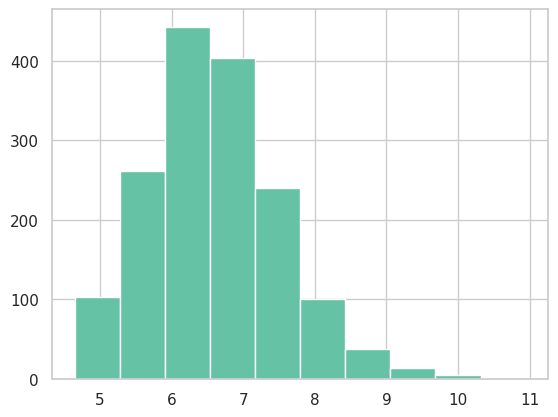

In [ ]:
drivers_df['rating'].hist()

Странно, рейтинг распределён около 7. Что же не так с данными?

### Вопрос в зал: почему так?

**Ответ:** из-за разного формата оценок (1–5 или процентный).

### 2.2. Sanity check 1. Полнота данных

Посмотрим на полноту данных заказов, а именно на id клиентов.

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342209 entries, 0 to 342208
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           342209 non-null  int64  
 1   data         342209 non-null  object 
 2   taxist       338818 non-null  object 
 3   client       338747 non-null  object 
 4   r1           51331 non-null   float64
 5   r2           171105 non-null  float64
 6   tariff       324921 non-null  object 
 7   len          342209 non-null  object 
 8   time         342209 non-null  object 
 9   coef         342209 non-null  float64
 10  cost         342209 non-null  int64  
 11  auto         342209 non-null  int64  
 12  service_fee  342209 non-null  float64
dtypes: float64(4), int64(3), object(6)
memory usage: 33.9+ MB


Полнота — 99%, но тип `object`. Посмотрим, что внутри данных.

In [ ]:
orders_df['client'].head(30)

,client
0,1
1,1
2,Глеб В.
3,2
4,2
5,2
6,2
7,2
8,2
9,Алексей Н.


Теперь понятно: у нас вместо id клиента иногда указано его имя.


### Вопрос в зал: стоит ли заниматься «угадыванием» клиента по имени?

**Ответ:** давайте оценим количество таких данных.

In [ ]:
(orders_df['client'].apply(lambda x: str(x).isdigit())).mean()

np.float64(0.9497763062923535)

95% данных корректны, при этом при «угадывании» мы можем получить некорректные данные. Вывод: угадывать не нужно, стоит заменить некорректные данные на пропуски.

### 2.4. Sanity check 3. Дубли

Посмотрим на дубли по id заказа.

In [ ]:
len(orders_df), len(orders_df['id'].unique())

(342209, 342209)

Дублей нет, и на том спасибо. :)

### Обработаем данные.

In [ ]:
# Преобразуем оценки
def clean_rating(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    if x > 5:
        return x / 20
    return x

orders_df['r1'] = orders_df['r1'].apply(clean_rating)
orders_df['r2'] = orders_df['r2'].apply(clean_rating)

orders_df

,id,data,taxist,client,r1,r2,tariff,len,time,coef,cost,auto,service_fee
0,1,2024-09-10,1344,1,NaN,NaN,эконом,43481.2 m,61.4 min,1.17,1155,443,231.0
1,2,2024-09-10,357,1,NaN,5.0,эконом,37.23 km,73.44 min,1.03,1064,123,212.8
2,3,2024-09-12,Рамазан К.,Глеб В.,NaN,NaN,эконом,30.52 km,48.7 min,1.10,818,708,163.6
3,4,2024-09-26,424,2,NaN,5.0,эконом,8.79 km,14.0 min,1.24,263,1261,52.6
4,5,2024.09.24,1507,2,5.0,5.0,комфорт+,5.0 km,7.77 min,1.14,290,1045,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342204,342205,2024-09-16,61,97565,NaN,5.0,комфорт,49.4 km,97.46 min,0.93,2187,1457,437.4
342205,342206,2024-09-04,745,97566,5.0,4.0,эконом,50.0 km,73.1 min,0.89,1034,739,206.8
342206,342207,2024-09-10,1239,97567,NaN,NaN,эконом,35.0 km,45.0 min,1.39,1053,177,210.6
342207,342208,2024-09-29,1595,97567,NaN,NaN,эконом,21.83 km,1691.0 sec,0.94,444,1414,88.8


In [ ]:
# Преобразуем длину маршрута
def clean_length(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        if 'km' in x:
            return float(re.sub(r'[^0-9.]', '', x))
        elif 'm' in x:
            return float(re.sub(r'[^0-9.]', '', x)) / 1000
        else:
            return float(x)
    return float(x)

orders_df['len'] = orders_df['len'].apply(clean_length)
orders_df

,id,data,taxist,client,r1,r2,tariff,len,time,coef,cost,auto,service_fee
0,1,2024-09-10,1344,1,NaN,NaN,эконом,43.4812,61.4 min,1.17,1155,443,231.0
1,2,2024-09-10,357,1,NaN,5.0,эконом,37.2300,73.44 min,1.03,1064,123,212.8
2,3,2024-09-12,Рамазан К.,Глеб В.,NaN,NaN,эконом,30.5200,48.7 min,1.10,818,708,163.6
3,4,2024-09-26,424,2,NaN,5.0,эконом,8.7900,14.0 min,1.24,263,1261,52.6
4,5,2024.09.24,1507,2,5.0,5.0,комфорт+,5.0000,7.77 min,1.14,290,1045,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342204,342205,2024-09-16,61,97565,NaN,5.0,комфорт,49.4000,97.46 min,0.93,2187,1457,437.4
342205,342206,2024-09-04,745,97566,5.0,4.0,эконом,50.0000,73.1 min,0.89,1034,739,206.8
342206,342207,2024-09-10,1239,97567,NaN,NaN,эконом,35.0000,45.0 min,1.39,1053,177,210.6
342207,342208,2024-09-29,1595,97567,NaN,NaN,эконом,21.8300,1691.0 sec,0.94,444,1414,88.8


### ✍️ Практика: преобразование времени поездки

In [ ]:
# Преобразуем время поездки
def clean_time(x):
    # Напиши код <...>
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        if 'min' in x:
            return float(re.sub(r'[^0-9.]', '', x))
        elif 'sec' in x:
            return float(re.sub(r'[^0-9.]', '', x)) / 60
        else:
            return float(x)
    return float(x)

orders_df['time'] = orders_df['time'].apply(clean_time)
orders_df

,id,data,taxist,client,r1,r2,tariff,len,time,coef,cost,auto,service_fee
0,1,2024-09-10,1344,1,NaN,NaN,эконом,43.4812,61.400000,1.17,1155,443,231.0
1,2,2024-09-10,357,1,NaN,5.0,эконом,37.2300,73.440000,1.03,1064,123,212.8
2,3,2024-09-12,Рамазан К.,Глеб В.,NaN,NaN,эконом,30.5200,48.700000,1.10,818,708,163.6
3,4,2024-09-26,424,2,NaN,5.0,эконом,8.7900,14.000000,1.24,263,1261,52.6
4,5,2024.09.24,1507,2,5.0,5.0,комфорт+,5.0000,7.770000,1.14,290,1045,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342204,342205,2024-09-16,61,97565,NaN,5.0,комфорт,49.4000,97.460000,0.93,2187,1457,437.4
342205,342206,2024-09-04,745,97566,5.0,4.0,эконом,50.0000,73.100000,0.89,1034,739,206.8
342206,342207,2024-09-10,1239,97567,NaN,NaN,эконом,35.0000,45.000000,1.39,1053,177,210.6
342207,342208,2024-09-29,1595,97567,NaN,NaN,эконом,21.8300,28.183333,0.94,444,1414,88.8


In [ ]:
# Преобразуем время
# Список форматов, которые мы ожидаем
date_formats = [
    "%Y-%m-%d",        # 2024-09-01
    "%d.%m.%Y",        # 01.09.2024
    "%d/%m/%Y",        # 01/09/2024
    "%d-%b-%Y",        # 01-Sep-2024
    "%Y/%m/%d",        # 2024/09/01
    "%Y.%m.%d",        # 2024.09.01
]

def parse_date_with_formats(date_str):
    if pd.isna(date_str):
        return pd.NaT
    for fmt in date_formats:
        try:
            return datetime.strptime(date_str, fmt)
        except (ValueError, TypeError):
            continue
    # Если ни один формат не подошёл, вернём NaT
    return pd.NaT


orders_df['data'] = pd.to_datetime(orders_df['data'].apply(parse_date_with_formats))
orders_df

,id,data,taxist,client,r1,r2,tariff,len,time,coef,cost,auto,service_fee
0,1,2024-09-10,1344,1,NaN,NaN,эконом,43.4812,61.400000,1.17,1155,443,231.0
1,2,2024-09-10,357,1,NaN,5.0,эконом,37.2300,73.440000,1.03,1064,123,212.8
2,3,2024-09-12,Рамазан К.,Глеб В.,NaN,NaN,эконом,30.5200,48.700000,1.10,818,708,163.6
3,4,2024-09-26,424,2,NaN,5.0,эконом,8.7900,14.000000,1.24,263,1261,52.6
4,5,2024-09-24,1507,2,5.0,5.0,комфорт+,5.0000,7.770000,1.14,290,1045,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342204,342205,2024-09-16,61,97565,NaN,5.0,комфорт,49.4000,97.460000,0.93,2187,1457,437.4
342205,342206,2024-09-04,745,97566,5.0,4.0,эконом,50.0000,73.100000,0.89,1034,739,206.8
342206,342207,2024-09-10,1239,97567,NaN,NaN,эконом,35.0000,45.000000,1.39,1053,177,210.6
342207,342208,2024-09-29,1595,97567,NaN,NaN,эконом,21.8300,28.183333,0.94,444,1414,88.8


In [ ]:
# Очистим id таксиста и клиента
orders_df['taxist'] = pd.to_numeric(orders_df['taxist'].apply(lambda x: x if str(x).isdigit() else np.nan))
orders_df['client'] = pd.to_numeric(orders_df['client'].apply(lambda x: x if str(x).isdigit() else np.nan))

In [ ]:
# Пересчитаем рейтинги
driver_ratings = orders_df.groupby('taxist')[['r1']].mean().reset_index().astype(float)
client_ratings = orders_df.groupby('client')[['r2']].mean().reset_index().astype(float)

drivers_df = drivers_df.merge(driver_ratings, how='left', left_on='id', right_on='taxist')
drivers_df['rating'] = drivers_df['r1']
drivers_df.drop(columns=['taxist', 'r1'], inplace=True)

clients_df = clients_df.merge(client_ratings, how='left', left_on='id', right_on='client')
clients_df['rating'] = clients_df['r2']
clients_df.drop(columns=['client', 'r2'], inplace=True)

drivers_df

,id,first_name,last_name,auto,rating,city
0,1,Рамазан,Багаев,1566,4.942857,Долгопрудный
1,2,Рамазан,Абдурахман,1619,4.700000,Москва
2,3,Жомарт,Назаров,1671,4.960000,Москва
3,4,Бауржан,Абдуллаев,1334,4.875000,Москва
4,5,Рустам,Юсупов,316,4.709677,Москва
...,...,...,...,...,...,...
1604,1605,Рустам,Жумаев,745,4.783784,Москва
1605,1606,Шамиль,Шарипов,1765,4.864865,Химки
1606,1607,Бауржан,Абдрахманов,1625,4.771429,Долгопрудный
1607,1608,Жомарт,Абдуллаев,5,4.885714,Москва


### ✍️ Практика: преобразование тарифов

In [ ]:
# Преобразуем тарифы
# Напиши код <...>
tariff_dict = {'э': 'эконом', 'к': 'комфорт', 'к+': 'комфорт+'}

orders_df['tariff'] = orders_df['tariff'].replace(tariff_dict)
orders_df

,id,data,taxist,client,r1,r2,tariff,len,time,coef,cost,auto,service_fee
0,1,2024-09-10,1344.0,1.0,NaN,NaN,эконом,43.4812,61.400000,1.17,1155,443,231.0
1,2,2024-09-10,357.0,1.0,NaN,5.0,эконом,37.2300,73.440000,1.03,1064,123,212.8
2,3,2024-09-12,NaN,NaN,NaN,NaN,эконом,30.5200,48.700000,1.10,818,708,163.6
3,4,2024-09-26,424.0,2.0,NaN,5.0,эконом,8.7900,14.000000,1.24,263,1261,52.6
4,5,2024-09-24,1507.0,2.0,5.0,5.0,комфорт+,5.0000,7.770000,1.14,290,1045,58.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
342204,342205,2024-09-16,61.0,97565.0,NaN,5.0,комфорт,49.4000,97.460000,0.93,2187,1457,437.4
342205,342206,2024-09-04,745.0,97566.0,5.0,4.0,эконом,50.0000,73.100000,0.89,1034,739,206.8
342206,342207,2024-09-10,1239.0,97567.0,NaN,NaN,эконом,35.0000,45.000000,1.39,1053,177,210.6
342207,342208,2024-09-29,1595.0,97567.0,NaN,NaN,эконом,21.8300,28.183333,0.94,444,1414,88.8


<Axes: >

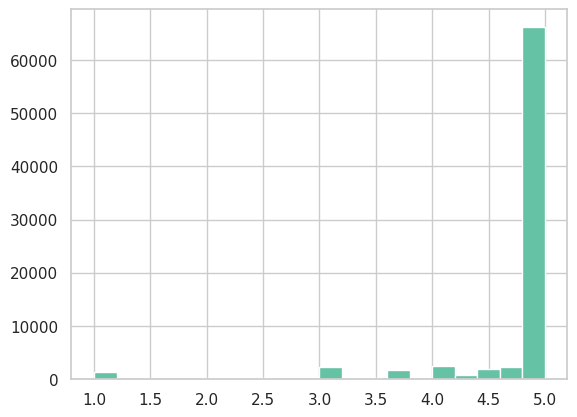

In [ ]:
clients_df['rating'].hist(bins=20)

<Axes: >

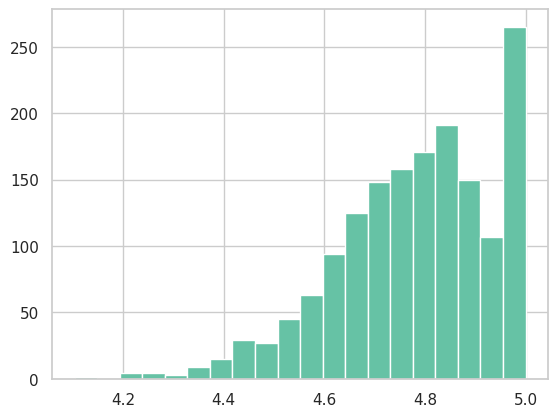

In [ ]:
drivers_df['rating'].hist(bins=20)

In [ ]:
# Обработаем данные по авто
def process_cars(x):
    return x['data']['марка'], x['data']['модель'], x['data']['тариф'], x['data']['аренда']

cars_df['data'] = cars_df['data'].apply(eval)
cars_df[['mark', 'model', 'tariff', 'rent_cost']] = cars_df.apply(process_cars, axis=1, result_type='expand')
cars_df.drop(columns=['data'], inplace=True)
cars_df

,id,mark,model,tariff,rent_cost
0,1,Daewoo,Matiz,эконом,1550
1,2,Fiat,Panda,эконом,1700
2,3,Fiat,Panda,эконом,1550
3,4,Renault,Logan,эконом,1400
4,5,Renault,Logan,эконом,1500
...,...,...,...,...,...
1808,1809,Citroen,C4,комфорт,2250
1809,1810,Daewoo,Matiz,эконом,1350
1810,1811,Geely,Emgrand,комфорт,2400
1811,1812,Nissan,Qashqai,комфорт+,2450


In [ ]:
cars_df

,id,mark,model,tariff,rent_cost
0,1,Daewoo,Matiz,эконом,1550
1,2,Fiat,Panda,эконом,1700
2,3,Fiat,Panda,эконом,1550
3,4,Renault,Logan,эконом,1400
4,5,Renault,Logan,эконом,1500
...,...,...,...,...,...
1808,1809,Citroen,C4,комфорт,2250
1809,1810,Daewoo,Matiz,эконом,1350
1810,1811,Geely,Emgrand,комфорт,2400
1811,1812,Nissan,Qashqai,комфорт+,2450


In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342209 entries, 0 to 342208
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           342209 non-null  int64         
 1   data         342209 non-null  datetime64[ns]
 2   taxist       325258 non-null  float64       
 3   client       325022 non-null  float64       
 4   r1           51331 non-null   float64       
 5   r2           171105 non-null  float64       
 6   tariff       324921 non-null  object        
 7   len          342209 non-null  float64       
 8   time         342209 non-null  float64       
 9   coef         342209 non-null  float64       
 10  cost         342209 non-null  int64         
 11  auto         342209 non-null  int64         
 12  service_fee  342209 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 33.9+ MB


<Axes: >

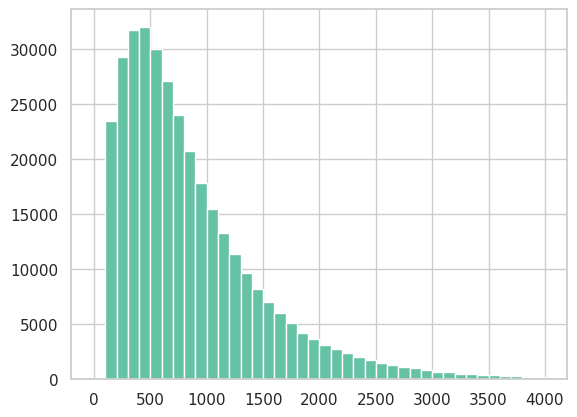

In [ ]:
orders_df['cost'].hist(bins=np.linspace(0, 4000, 41))

**Вернёмся к заданию:** построй статистику по тарифам и сделай вывод, какие тарифы выгоднее использовать водителям, а какие — компании.

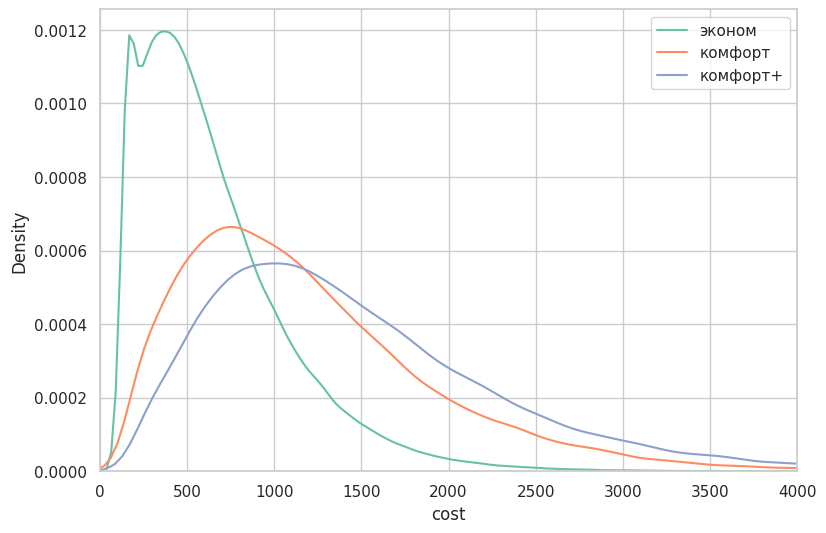

In [ ]:
plt.figure(figsize=(9, 6))
orders_econom = orders_df[orders_df['tariff'] == 'эконом']
orders_comfort = orders_df[orders_df['tariff'] == 'комфорт']
orders_comfort_plus = orders_df[orders_df['tariff'] == 'комфорт+']

sns.kdeplot(orders_econom['cost'], label='эконом')
sns.kdeplot(orders_comfort['cost'], label='комфорт')
sns.kdeplot(orders_comfort_plus['cost'], label='комфорт+')
plt.xlim((0, 4000))
plt.legend()
plt.show()

<Axes: >

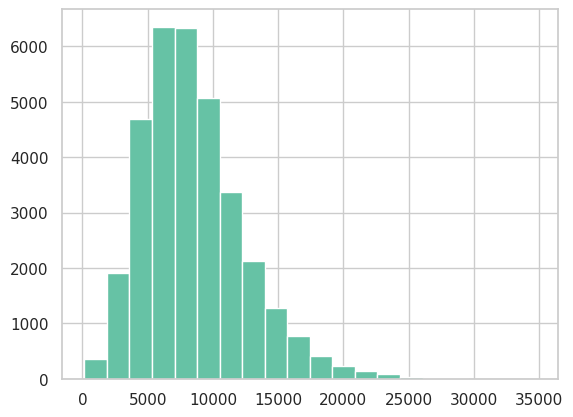

In [ ]:
orders_group = orders_df.groupby(['taxist', 'data']).agg({
    'id': 'count',
    'cost': 'sum',
    'service_fee': 'sum'
}).reset_index().rename(columns={'id': 'orders_cnt', 'cost': 'total_cost',
                                 'service_fee': 'total_service_fee', 'data': 'date'})
orders_group['taxist'] = orders_group['taxist'].astype(int)
orders_group['total_cost'].hist(bins=20)

### 2.5. Sanity check 4. Неправильные ключи


**Вопрос в зал:** мы хотим сегментировать заказы по тарифам автомобилей и посчитать доходы таксиста и доходы компании от работы таксистов. Как нам это сделать?


**Ответ:**
- доход водителя — это выручка − комиссия − аренда автомобиля;
- доход компании — это комиссия + аренда автомобиля;
- к сгруппированным данным надо присоединить водителя, а потом к его авто присоединить данные по авто.
- Как соединять? Изучаем таблички.

In [ ]:
orders_group = orders_group.merge(drivers_df[['id', 'auto']],
                                  left_on='taxist', right_on='id').rename(columns={
    'taxist': 'taxist_id'
}).drop(columns=['id'])
orders_group = orders_group.merge(cars_df[['id', 'tariff', 'rent_cost']],
                                  left_on='auto', right_on='id').rename(columns={
    'auto': 'auto_id'
}).drop(columns=['id'])
orders_group['driver_income'] = orders_group['total_cost'] - orders_group['total_service_fee'] - orders_group['rent_cost']
orders_group['company_income'] = orders_group['total_service_fee'] + orders_group['rent_cost']
orders_group

,taxist,data,id_x,cost,service_fee,id_y,auto,id,tariff,rent_cost,driver_income,company_income
0,1.0,2024-09-01,15,10875,2175.0,1,1566,1566,эконом,1300,7400.0,3475.0
1,1.0,2024-09-03,16,9368,1873.6,1,1566,1566,эконом,1300,6194.4,3173.6
2,1.0,2024-09-06,5,3646,729.2,1,1566,1566,эконом,1300,1616.8,2029.2
3,1.0,2024-09-07,13,7523,1504.6,1,1566,1566,эконом,1300,4718.4,2804.6
4,1.0,2024-09-10,21,12245,2449.0,1,1566,1566,эконом,1300,8496.0,3749.0
...,...,...,...,...,...,...,...,...,...,...,...,...
33200,1609.0,2024-09-25,10,5299,1059.8,1609,1386,1386,эконом,1600,2639.2,2659.8
33201,1609.0,2024-09-27,11,7660,1532.0,1609,1386,1386,эконом,1600,4528.0,3132.0
33202,1609.0,2024-09-28,16,13524,2704.8,1609,1386,1386,эконом,1600,9219.2,4304.8
33203,1609.0,2024-09-29,9,4978,995.6,1609,1386,1386,эконом,1600,2382.4,2595.6


Строим оценку плотности распределения доходов водителей.

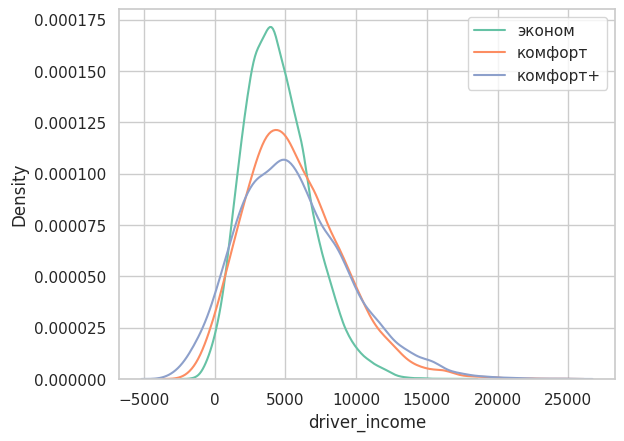

In [ ]:
orders_group_econom = orders_group[orders_group['tariff'] == 'эконом']
orders_group_comfort = orders_group[orders_group['tariff'] == 'комфорт']
orders_group_comfort_plus = orders_group[orders_group['tariff'] == 'комфорт+']

sns.kdeplot(orders_group_econom['driver_income'], label='эконом')
sns.kdeplot(orders_group_comfort['driver_income'], label='комфорт')
sns.kdeplot(orders_group_comfort_plus['driver_income'], label='комфорт+')
# plt.xlim((0, 4000))
plt.legend()
plt.show()

Строим оценку плотности распределения доходов компании с одного водителя.

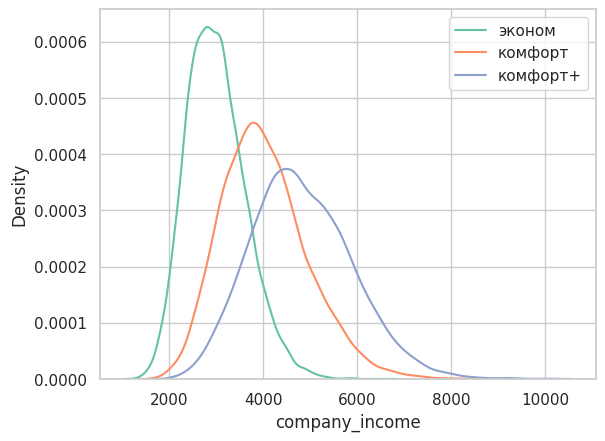

In [ ]:
orders_group_econom = orders_group[orders_group['tariff'] == 'эконом']
orders_group_comfort = orders_group[orders_group['tariff'] == 'комфорт']
orders_group_comfort_plus = orders_group[orders_group['tariff'] == 'комфорт+']

sns.kdeplot(orders_group_econom['company_income'], label='эконом')
sns.kdeplot(orders_group_comfort['company_income'], label='комфорт')
sns.kdeplot(orders_group_comfort_plus['company_income'], label='комфорт+')
# plt.xlim((0, 4000))
plt.legend()
plt.show()

Оценим также, сколько компания зарабатывает со всех водителей с определённым тарифом в день.

In [ ]:
orders_group_tariff = orders_group.groupby(['date', 'tariff'])['company_income'].sum().reset_index()
orders_group_tariff

,data,tariff,company_income
0,2024-09-01,комфорт,849502.6
1,2024-09-01,комфорт+,1033683.2
2,2024-09-01,эконом,2030359.6
3,2024-09-02,комфорт,898175.6
4,2024-09-02,комфорт+,1098162.0
...,...,...,...
85,2024-09-29,комфорт+,1057443.8
86,2024-09-29,эконом,1874738.8
87,2024-09-30,комфорт,885203.6
88,2024-09-30,комфорт+,1026247.4


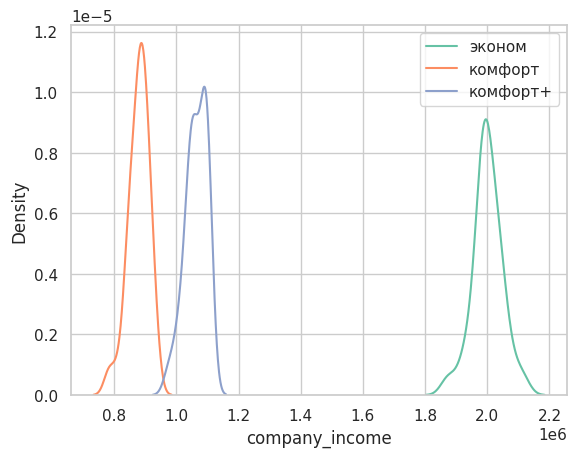

In [ ]:
orders_group_tariff_econom = orders_group_tariff[orders_group_tariff['tariff'] == 'эконом']
orders_group_tariff_comfort = orders_group_tariff[orders_group_tariff['tariff'] == 'комфорт']
orders_group_tariff_comfort_plus = orders_group_tariff[orders_group_tariff['tariff'] == 'комфорт+']

sns.kdeplot(orders_group_tariff_econom['company_income'], label='эконом')
sns.kdeplot(orders_group_tariff_comfort['company_income'], label='комфорт')
sns.kdeplot(orders_group_tariff_comfort_plus['company_income'], label='комфорт+')
# plt.xlim((0, 4000))
plt.legend()
plt.show()

Посмотрим на распределение количества заказов.

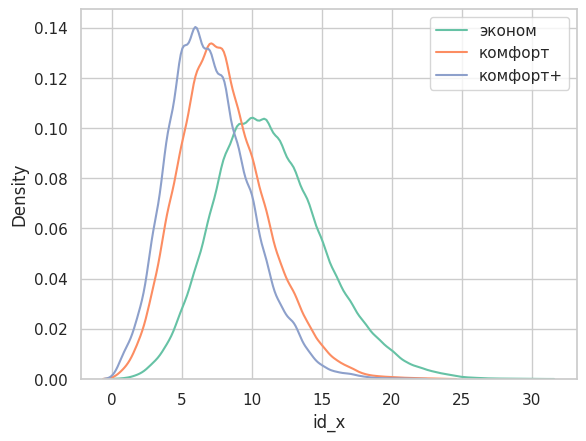

In [ ]:
sns.kdeplot(orders_group_econom['id_x'], label='эконом')
sns.kdeplot(orders_group_comfort['id_x'], label='комфорт')
sns.kdeplot(orders_group_comfort_plus['id_x'], label='комфорт+')
# plt.xlim((0, 4000))
plt.legend()
plt.show()

> ***Вывод по задаче***  


- Доход водителя

    * **Что видно:**

      * для тарифа **«Эконом»** (зелёный) пик плотности дохода ниже и уже, максимум — около 5 000 ₽;
      * для тарифов **«Комфорт»** и **«Комфорт+»** кривая шире, хвост длиннее, доходы в среднем выше.
    * **Инсайт:**
      таксисты на тарифах **«Комфорт»** и **«Комфорт+»** потенциально зарабатывают больше, но разброс больше: кто-то может уехать далеко и дорого, кто-то просто сидит без заказов. **«Эконом»** более стабилен, но доход ниже.

---

- Доход компании с одного водителя

    * **Что видно:**

      * тот же порядок: **«Эконом»** < **«Комфорт»** < **«Комфорт+»**;
      * разброс плотности тоже шире у более дорогих тарифов.
    * **Инсайт:**
      для компании выгоднее, если таксист работает на более дорогом тарифе (комиссия и наценка растут пропорционально среднему чеку).

---

- Доход компании со всех водителей тарифа

    * **Что видно:**

      * тут неожиданно видно, что **«Эконом»** даёт самый большой вклад: пик — далеко вправо;
      * **«Комфорт»** и **«Комфорт+»** дают меньше.
    * **Инсайт:**
      почему так? Потому что таких таксистов больше! **«Эконом»** массовый, значит, больше поездок и суммарный вклад в выручку больше, даже если с одного водителя она ниже.
      Это подтверждает логику агрегаторов: массовые дешёвые поездки — основа оборота.

---

- Заказы в день:

    * **«Эконом»** имеет больше заказов в день;
    * это логично, ведь поездки короткие, заказов много;
    * **«Комфорт+»** — реже, но дороже.

**Вывод**

* Если ты водитель, тебе выгоднее работать на более высоком тарифе, **если есть заказы и машина подходит**.
* Если ты компания (агрегатор), тебе выгоднее массово продавать **«Эконом»**, а премиум держать для лояльных клиентов и имиджа.
* Однако большинство клиентов заказывают эконом.

## 3. Итоги семинара

С чем выходим с занятия:

- вспомнили принципы работы с данными (ознакомиться с описанием данных, проверить данные на правдоподобность, проверить, есть ли дубли в данных, при соединении данных убедиться в правильности ключей, считать метрики так, как это принято в компании);
- посмотрели на принципы на примере;
- попрактиковались в очищении данных;
- сделали небольшое исследование и выводы из него.

## 4. Полезные материалы

- [Вредные советы при построении аналитики](https://habr.com/ru/companies/otus/articles/650471/)
- [Про витрины данных](https://www.decosystems.ru/data-mart/)